In [1]:
# Necessary Dependencies
import numpy as np
import pandas as pd
# !pip install utils - Removed for local execution
try:
    from utils import *
except ImportError:
    pass # In case utils is not available locally
from glob import glob
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from itertools import chain
from datetime import datetime
import statistics
from tqdm import tqdm
import tensorflow as tf

# Configure GPU memory growth for local execution
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Configured {len(gpus)} GPU(s) for memory growth.")
    except RuntimeError as e:
        print(e)

# DenseNet Dependencies
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.layers import Dense,Conv2D, Flatten, Dropout, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16
from keras import backend as K
from tensorflow.keras import Sequential
import keras
import matplotlib
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from sklearn.metrics import roc_curve, auc
print('Started')

Started


In [2]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/train",
seed=123,
image_size=(224, 224),
batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/test",
seed=123,
image_size=(224, 224),
batch_size=32,
    shuffle=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/val",
seed=123,
image_size=(224, 224),
batch_size=32
)

Found 5778 files belonging to 5 classes.
Found 1656 files belonging to 5 classes.
Found 826 files belonging to 5 classes.


In [ ]:
import cv2
import numpy as np

# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe_to_batch(images, labels):
    def _clahe_py_func(imgs):
        imgs = imgs.numpy().astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        clahe_batch = np.empty_like(imgs)
        # Iterate over the batch of images
        for i in range(imgs.shape[0]):
            img = imgs[i]
            # Convert to LAB color space to apply equalization ONLY to the L (Luma/Lightness) channel
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            # Convert back to RGB space
            clahe_batch[i] = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            
        return clahe_batch.astype(np.float32)
        
    clahe_images = tf.py_function(func=_clahe_py_func, inp=[images], Tout=tf.float32)
    clahe_images.set_shape(images.shape)
    return clahe_images, labels

print("Mapping CLAHE (Contrast Enhancement) to pipelines...")
train_ds = train_ds.map(apply_clahe_to_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(apply_clahe_to_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
# It's also important to apply standard metrics to testing so it's consistent
test_ds = test_ds.map(apply_clahe_to_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


In [3]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true

array([0, 0, 0, ..., 4, 4, 4])

In [4]:
def get_callbacks(model_name):
    callbacks =[]

    # Change the file extension to '.keras'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.keras',
                                                    verbose=1,
                                                    monitor='val_loss',
                                                    mode='min',
                                                    save_best_only=False)
    callbacks.append(checkpoint)
    #--------------------------------------------------------
    anne = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.5,
                             patience=5,
                             verbose=2,
                             min_lr=0.0000001,
                             min_delta=0.00001,
                             mode='auto')
    callbacks.append(anne)
    #--------------------------------------------------------
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                 patience=10)
    callbacks.append(earlystop)

    return callbacks

In [ ]:
# Xception Model
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Initialize the model WITHOUT downloading weights
base_model = tf.keras.applications.Xception(
    weights=None, # Changed from 'imagenet' to None
    input_shape=(224, 224, 3),
    include_top=False
)

# 2. Load the downloaded weights manually
base_model.load_weights('xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

# --- PHASE 1: Feature Extraction ---
# Freeze the base model
base_model.trainable = False

# Add classification head with Augmented inputs and Dropout
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(224, 224, 3)),
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
  tf.keras.layers.RandomContrast(0.1),
  tf.keras.layers.Rescaling(scale=1./127.5, offset=-1),
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),        # Flatten
  tf.keras.layers.Dropout(0.5),                    # High dropout for regularization
  tf.keras.layers.Dense(5, activation='softmax')   # Classification Layer
])

#----------------------------------------------------
# Compile Phase 1 (Higher Learning Rate)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#----------------------------------------------------
print("Calculating class weights...")
# Extracting labels efficiently from tf.data.Dataset
y_train_list = []
for images, labels in train_ds:
    y_train_list.append(labels.numpy())

if y_train_list:
    y_train_arr = np.concatenate(y_train_list, axis=0)
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_arr), y=y_train_arr)
    class_weight_dict = dict(enumerate(class_weights))
    print(f"Class weights computed: {class_weight_dict}")
else:
    class_weight_dict = None

callbacks_phase1 = get_callbacks('Xception_Phase1')

print("Starting Phase 1 Training: Warm-up the Classification Head (10 Epochs)")
history_phase1 = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=10,
                callbacks=callbacks_phase1,
                class_weight=class_weight_dict
                )

# --- PHASE 2: Fine-Tuning ---
# Unfreeze the base model
base_model.trainable = True

# Compile Phase 2 (Very Low Learning Rate to prevent catastrophic forgetting)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks_phase2 = get_callbacks('Xception_Phase2')

print("Starting Phase 2 Training: Fine-Tuning the Base Model (20 Epochs)")
history_phase2 = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=20,
                callbacks=callbacks_phase2,
                class_weight=class_weight_dict
                )


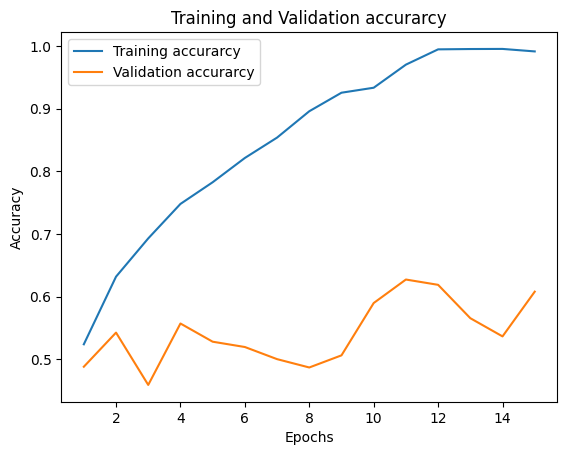

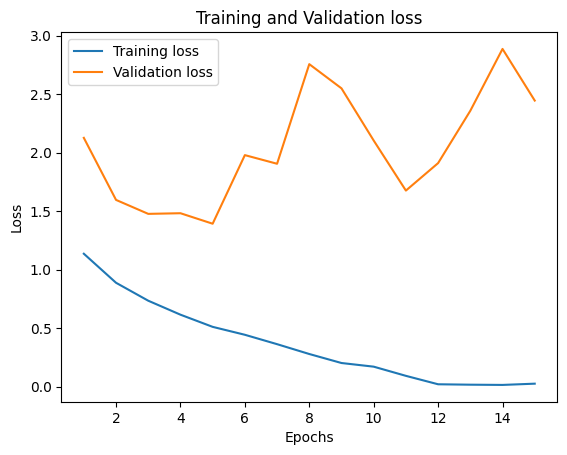

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
# Print the classiifcation report

from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
predicted_categories = np.argmax(y_pred, axis=1)
true_categories = y_true
print(classification_report(true_categories, predicted_categories, digits=4))


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 504ms/step
              precision    recall  f1-score   support

           0     0.7140    0.6761    0.6945       639
           1     0.2570    0.5608    0.3524       296
           2     0.7500    0.1879    0.3005       447
           3     0.7097    0.7892    0.7473       223
           4     0.8000    0.7059    0.7500        51

    accuracy                         0.5399      1656
   macro avg     0.6461    0.5840    0.5690      1656
weighted avg     0.6441    0.5399    0.5359      1656



In [14]:
# 1. Reload the training data but FORCE shuffle to False
eval_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./dataset-kaggle/train",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False  # <--- CRITICAL FIX!
)

# 2. Predict on the ordered dataset
y_pred1 = model.predict(eval_train_ds)
predicted_categories1 = np.argmax(y_pred1, axis=1)

# 3. Get ordered ground truths
y_true1 = np.concatenate([y for x, y in eval_train_ds], axis=0)
true_categories1 = y_true1

# 4. Report
print(classification_report(true_categories1, predicted_categories1, digits=4))

Found 5778 files belonging to 5 classes.
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 484ms/step
              precision    recall  f1-score   support

           0     0.8692    0.8666    0.8679      2286
           1     0.3963    0.7380    0.5157      1046
           2     0.9720    0.3437    0.5078      1516
           3     0.8610    0.9657    0.9103       757
           4     0.9819    0.9422    0.9617       173

    accuracy                         0.7214      5778
   macro avg     0.8161    0.7712    0.7527      5778
weighted avg     0.8129    0.7214    0.7180      5778



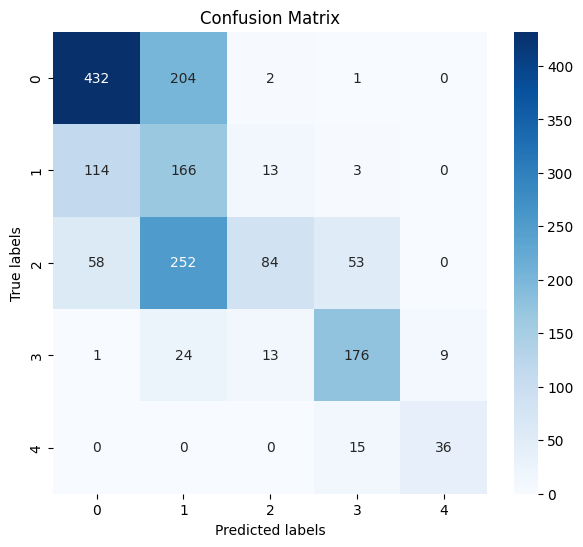

In [11]:
#  draw the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(true_categories, predicted_categories)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues') #xticklabels=target_names, yticklabels=target_names
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [12]:
model.save('./final_model_export.keras')
print("Model successfully exported and saved as 'final_model_export.keras'")

Model successfully exported and saved as 'final_model_export.keras'
